# Intro

* The formula and parameters for a 2D Gaussian
* More about implementing CNNs in PyTorch
* How to integrate classes and nn.Sequential to define custom models
* That the CNN learned filters (convolution kernels) are easy to look at but difficult to understand

# 2D Gaussians

$$ G = exp\Big(\frac{-(\widetilde{X}^2 + \widetilde{Y}^2)}{2\sigma^2} \Big)$$

$$ \widetilde{X} = X - C_x $$
$$ \widetilde{Y} = Y - C_y $$

* $\sigma$ - Full width of half maximum (spread)
* $X, Y$ - 2D of coordinates
* $C_x, C_y$ - Center locations

# Imports

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from torchsummary import summary

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt

# Gaussian Blurs

Let's create Gaussian blurs with 2 classes. Each class will have different width.

In [2]:
n_per_clust = 1000
img_size = 91
x = np.linspace(-4,4,img_size)
X, Y = np.meshgrid(x, x)

# two widths
widths = [1.8, 2.4]

# images and labels placeholders
images = torch.zeros(2*n_per_clust, 1, img_size, img_size)
labels = torch.zeros(2*n_per_clust)

for i in range(2*1000):
  ro = np.random.randn(2) # random offset
  G = np.exp(
      - ((X-ro[0])**2 + (Y-ro[1])**2) /
        (2*widths[i%2]**2) # every other label is odd or even due to i%2
  )

  # add noise
  G = G + np.random.randn(img_size, img_size) / 5

  # add image and label
  images[i,:,:,:] = torch.tensor(G).view(1,img_size, img_size)
  labels[i] = i%2

labels = labels[:,None]

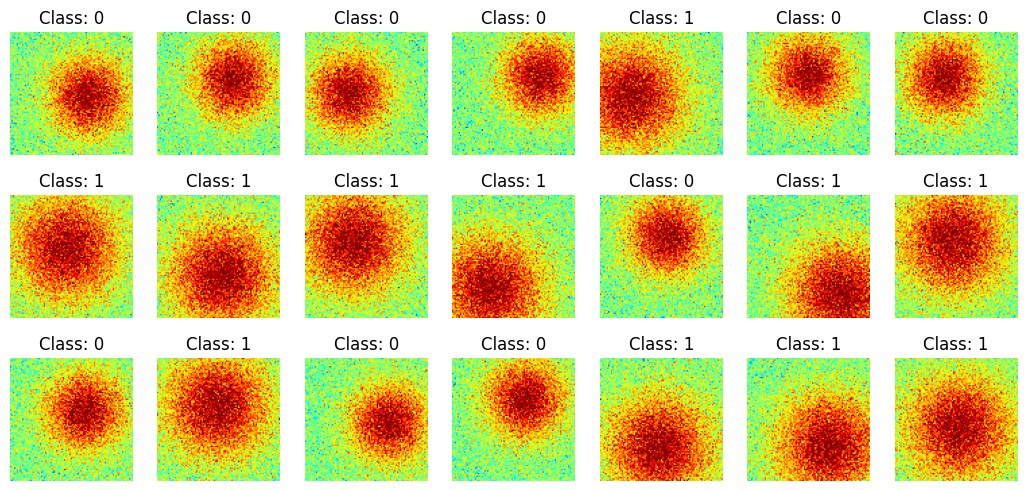

In [3]:
fig, axs = plt.subplots(3, 7, figsize = (13, 6))

for i, ax in enumerate(axs.flatten()):
  rand_row = np.random.randint(images.shape[0])
  ax.imshow(images[rand_row].squeeze(), vmin = -1, vmax = 1, cmap = 'jet')
  ax.set_title(f'Class: {labels[rand_row].item():.0f}')
  ax.axis('off')
  ax.set_xticks([])
  ax.set_yticks([])

plt.show()

# Train/Test DataLoader

In [4]:
train_data, test_data, train_labels, test_labels = train_test_split(images, labels, test_size = .2)

train_dataset = TensorDataset(train_data, train_labels)
test_dataset = TensorDataset(test_data, test_labels)

batch_size = 32
train_dataloader = DataLoader(train_dataset, batch_size = batch_size, shuffle = True)
test_dataloader = DataLoader(test_dataset, batch_size = test_data.shape[0], shuffle = False)

# Create DL Model

In [5]:
def CreateModel():

  class CreateNet(nn.Module):
    def __init__(self):
      super().__init__()

      self.enc = nn.Sequential(
          nn.Conv2d(1, 6, 3, 1, 1),   # out_size = ((in_size + 2*padding - kernel) / stride ) + 1 = ((91 + 2 - 3) / 1) + 1 = 91
          nn.ReLU(),
          nn.MaxPool2d(2,2),          # out_size = 91 // 2 = 45

          nn.Conv2d(6, 4, 3, 1, 1),   # out_size = (45 + 2 - 3) / 1 + 1 = 45
          nn.ReLU(),
          nn.MaxPool2d(2,2),          # out_size = 45 // 2 = 22

          nn.Flatten(),
          nn.Linear(22 * 22 * 4, 50),
          nn.Linear(50, 1)
      )

    def forward(self, x):
      x = self.enc(x)
      return x

  net = CreateNet()
  loss_fn = nn.BCEWithLogitsLoss()
  optimizer = torch.optim.Adam(net.parameters(), lr = 1e-3)

  return net, loss_fn, optimizer

In [6]:
net, loss_fn, optimizer = CreateModel()
X, y = next(iter(train_dataloader))
y_hat = net(X)
loss = loss_fn(y_hat, y)
loss

tensor(0.6918, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)

In [7]:
summary(net, (1, img_size, img_size))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1            [-1, 6, 91, 91]              60
              ReLU-2            [-1, 6, 91, 91]               0
         MaxPool2d-3            [-1, 6, 45, 45]               0
            Conv2d-4            [-1, 4, 45, 45]             220
              ReLU-5            [-1, 4, 45, 45]               0
         MaxPool2d-6            [-1, 4, 22, 22]               0
           Flatten-7                 [-1, 1936]               0
            Linear-8                   [-1, 50]          96,850
            Linear-9                    [-1, 1]              51
Total params: 97,181
Trainable params: 97,181
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.03
Forward/backward pass size (MB): 1.00
Params size (MB): 0.37
Estimated Total Size (MB): 1.41
---------------------------------------------

## Train Loop

In [8]:
def RunModel():
  # number of epochs
  epochs = 10

  # create a new model
  net, loss_fn, optimizer = CreateModel()

  # initialize losses
  train_losses = torch.zeros(epochs)
  test_losses = torch.zeros(epochs)
  train_accs = torch.zeros(epochs)
  test_accs = torch.zeros(epochs)

  for epoch in range(epochs):
    # loop over training data batches
    batch_losses = []
    batch_accs = []

    for X, y in train_dataloader:

      # forward pass and loss
      y_hat = net(X)
      loss = loss_fn(y_hat, y)

      # backprop
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      batch_acc = ((y_hat > 0).float() == y).float().mean().item()


      # batch loss and acc
      batch_losses.append(loss.item())
      batch_accs.append(batch_acc)


    # losses
    train_losses[epoch] = np.mean(batch_losses)
    train_accs[epoch] = 100 * np.mean(batch_accs)

    # test acc
    X, y = next(iter(test_dataloader))
    with torch.no_grad():
      y_hat = net(X)
      loss = loss_fn(y_hat, y)


    test_losses[epoch] = loss.item()
    test_acc = 100 * ((y_hat > 0).float() == y).float().mean().item()
    test_accs[epoch] = test_acc

    print(f'Epoch {epoch} Train Loss: {train_losses[epoch]:.4f}, Test Loss: {test_losses[epoch]:.4f}, Train Acc: {train_accs[epoch]:.4f}, Test Acc: {test_accs[epoch]:.4f}')

  return train_losses, test_losses, train_accs, test_accs, net

In [9]:
train_losses, test_losses, train_accs, test_accs, net = RunModel()

Epoch 0 Train Loss: 0.5012, Test Loss: 0.1138, Train Acc: 76.5625, Test Acc: 97.7500
Epoch 1 Train Loss: 0.0265, Test Loss: 0.0147, Train Acc: 99.7500, Test Acc: 99.5000
Epoch 2 Train Loss: 0.0048, Test Loss: 0.0073, Train Acc: 99.8750, Test Acc: 99.7500
Epoch 3 Train Loss: 0.0019, Test Loss: 0.0054, Train Acc: 100.0000, Test Acc: 99.7500
Epoch 4 Train Loss: 0.0012, Test Loss: 0.0041, Train Acc: 100.0000, Test Acc: 99.7500
Epoch 5 Train Loss: 0.0008, Test Loss: 0.0023, Train Acc: 100.0000, Test Acc: 100.0000
Epoch 6 Train Loss: 0.0007, Test Loss: 0.0022, Train Acc: 100.0000, Test Acc: 100.0000
Epoch 7 Train Loss: 0.0004, Test Loss: 0.0014, Train Acc: 100.0000, Test Acc: 100.0000
Epoch 8 Train Loss: 0.0004, Test Loss: 0.0023, Train Acc: 100.0000, Test Acc: 100.0000
Epoch 9 Train Loss: 0.0004, Test Loss: 0.0025, Train Acc: 100.0000, Test Acc: 99.7500


## Plots

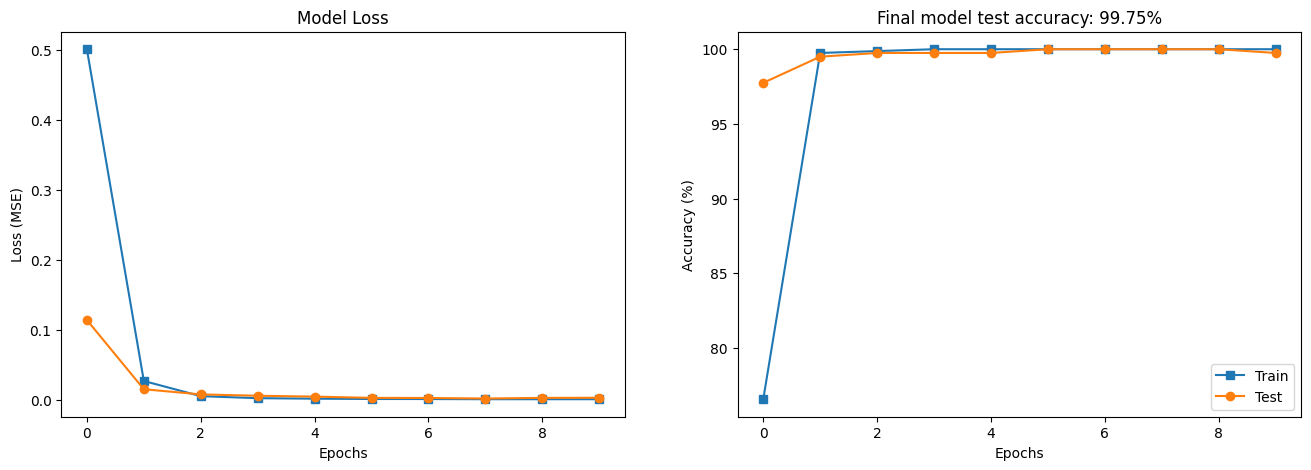

In [10]:
fig, ax = plt.subplots(1,2,figsize=(16,5))

ax[0].plot(train_losses, 's-', label = 'Train')
ax[0].plot(test_losses, 'o-', label = 'Test')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss (MSE)')
ax[0].set_title('Model Loss')

ax[1].plot(train_accs, 's-', label = 'Train')
ax[1].plot(test_accs, 'o-', label = 'Test')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Accuracy (%)')
ax[1].set_title(f'Final model test accuracy: {test_accs[-1]:.2f}%')
ax[1].legend()

plt.show()

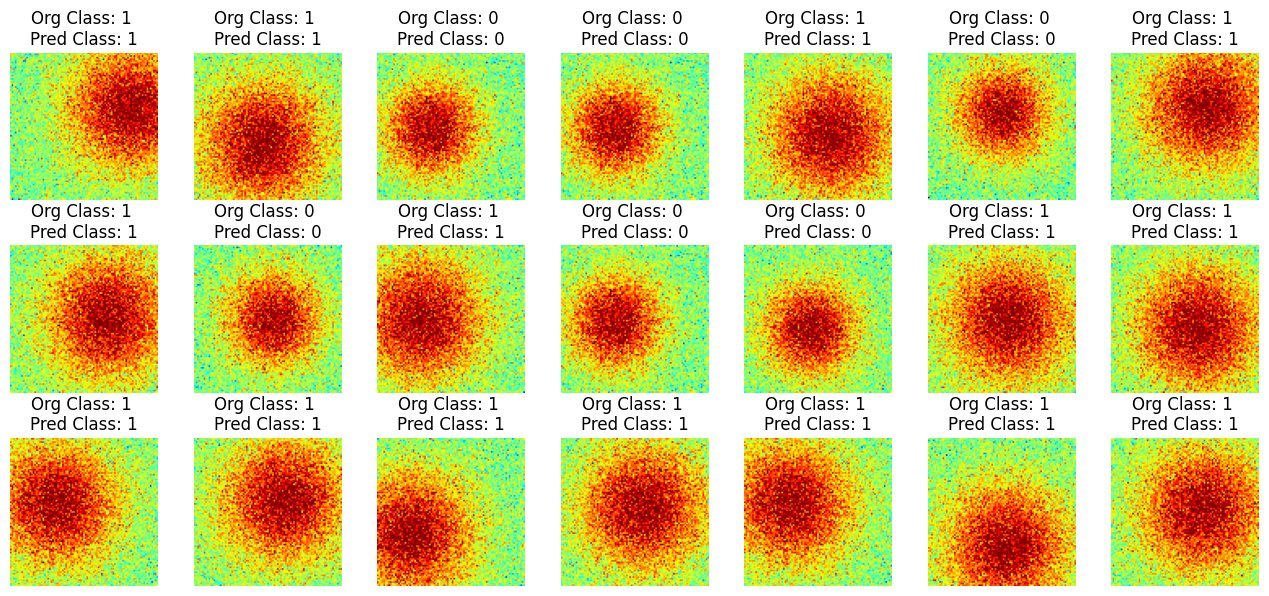

In [11]:
X, y = next(iter(train_dataloader))
y_hat = net(X)

fig, axs = plt.subplots(3, 7, figsize = (13, 6))

for i, ax in enumerate(axs.flatten()):
  rand_row = np.random.randint(X.shape[0])
  image = X[rand_row]
  ax.imshow(image.squeeze(), vmin = -1, vmax = 1, cmap = 'jet')
  ax.set_title(f'Org Class: {y[rand_row].item():.0f} \nPred Class: {int(y_hat[rand_row].item()>0)}')
  ax.axis('off')
  ax.set_xticks([])
  ax.set_yticks([])

plt.tight_layout()
plt.show()

## Filters

In [12]:
net

CreateNet(
  (enc): Sequential(
    (0): Conv2d(1, 6, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(6, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Flatten(start_dim=1, end_dim=-1)
    (7): Linear(in_features=1936, out_features=50, bias=True)
    (8): Linear(in_features=50, out_features=1, bias=True)
  )
)

In [13]:
layer_1w = net.enc[0].weight
layer_3w = net.enc[3].weight

layer_1w.shape, layer_3w.shape

(torch.Size([6, 1, 3, 3]), torch.Size([4, 6, 3, 3]))

### layer_1w

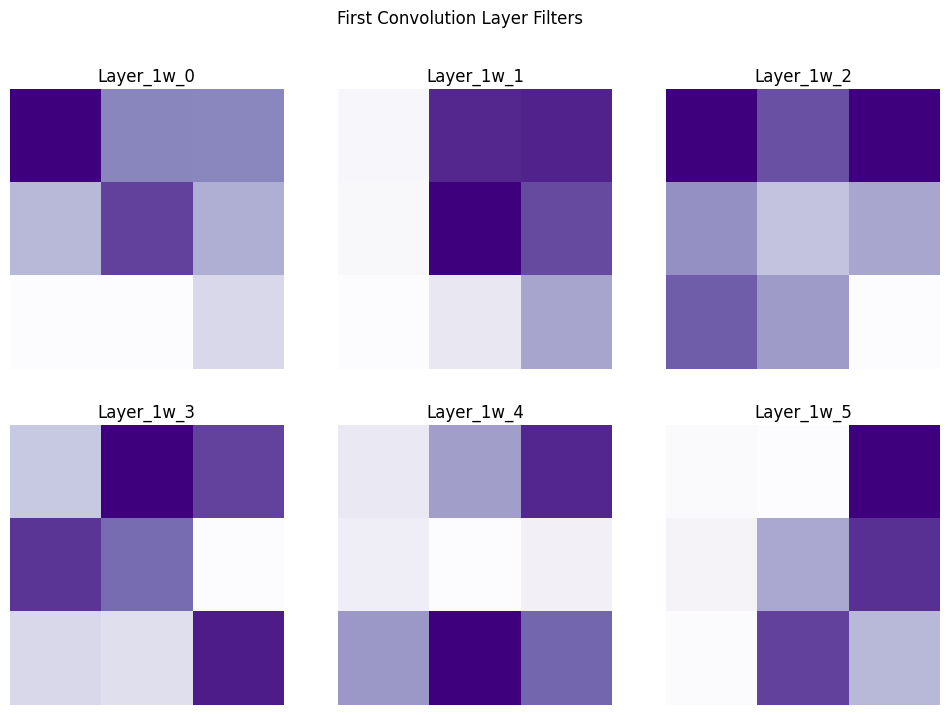

In [14]:
fig, axs = plt.subplots(2, 3, figsize = (12, 8))

for i, ax in enumerate(axs.flatten()):
  ax.imshow(layer_1w[i,:,:,:].detach().squeeze(), cmap = 'Purples', aspect = 'auto')
  ax.set_title(f'Layer_1w_{i}')
  ax.axis('off')

plt.suptitle('First Convolution Layer Filters')
plt.show()

### layer_3w

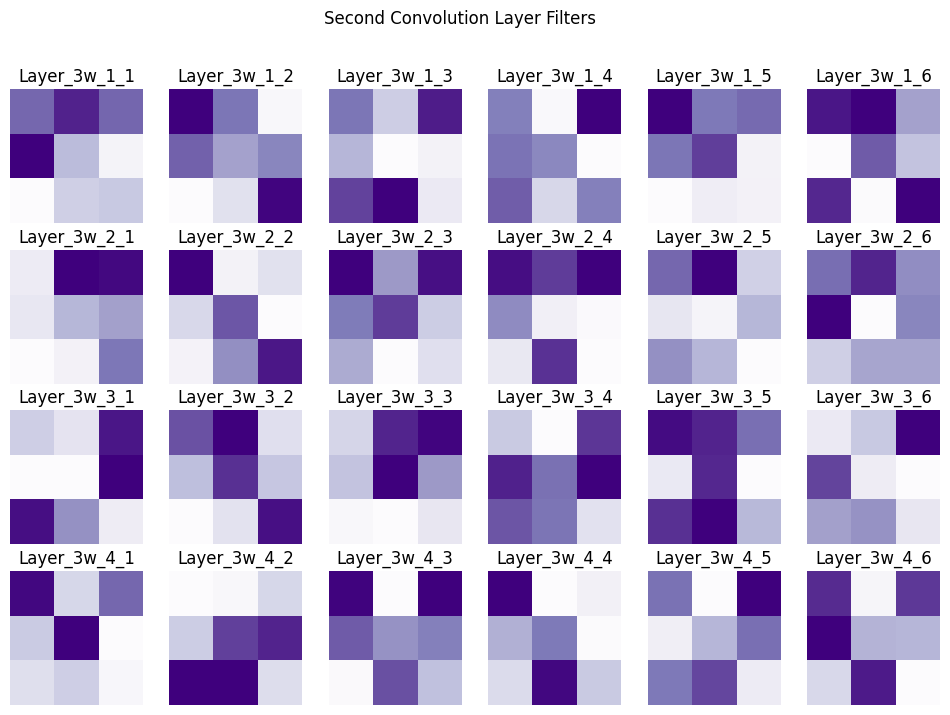

In [15]:
fig, axs = plt.subplots(4, 6, figsize = (12, 8))

for i in range(4):
  for j in range(6):
    axs[i][j].imshow(layer_3w[i,j,:,:].detach().squeeze(), cmap = 'Purples', aspect = 'auto')
    axs[i][j].set_title(f'Layer_3w_{i+1}_{j+1}')
    axs[i][j].axis('off')

plt.suptitle('Second Convolution Layer Filters')
plt.show()

# DL Model for Feature Maps

To check feature maps we need to extract output of each convolution layer

In [16]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from torchsummary import summary

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt

## Model

In [17]:
def CreateModel():

  class CreateNet(nn.Module):
    def __init__(self):
      super().__init__()

      self.relu = nn.ReLU()

      self.max_pool = nn.MaxPool2d(2,2)

      self.conv_1 = nn.Conv2d(1,6,3,1,1)

      self.conv_2 = nn.Conv2d(6,4,3,1,1)

      self.fc1 = nn.Linear(22*22*4, 50)

      self.fc2 = nn.Linear(50, 1)

    def forward(self, x):
      conv_1 = self.relu(self.conv_1(x))
      x = self.max_pool(conv_1)

      conv_2 = self.relu(self.conv_2(x))
      x = self.max_pool(conv_2)

      x = torch.flatten(x, 1)
      x = self.relu(self.fc1(x))
      x = self.fc2(x)
      return x, conv_1, conv_2

  net = CreateNet()
  loss_fn = nn.BCEWithLogitsLoss()
  optimizer = torch.optim.Adam(net.parameters(), lr = 1e-3)

  return net, loss_fn, optimizer

In [18]:
net, loss_fn, optimizer = CreateModel()
X, y = next(iter(train_dataloader))
y_hat, feature_map_1, feature_map_2 = net(X)
loss = loss_fn(y_hat, y)
loss

tensor(0.6888, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)

In [19]:
y_hat.shape

torch.Size([32, 1])

In [20]:
feature_map_1.shape

torch.Size([32, 6, 91, 91])

In [21]:
feature_map_2.shape

torch.Size([32, 4, 45, 45])

In [22]:
summary(net, (1, img_size, img_size))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1            [-1, 6, 91, 91]              60
              ReLU-2            [-1, 6, 91, 91]               0
         MaxPool2d-3            [-1, 6, 45, 45]               0
            Conv2d-4            [-1, 4, 45, 45]             220
              ReLU-5            [-1, 4, 45, 45]               0
         MaxPool2d-6            [-1, 4, 22, 22]               0
            Linear-7                   [-1, 50]          96,850
              ReLU-8                   [-1, 50]               0
            Linear-9                    [-1, 1]              51
Total params: 97,181
Trainable params: 97,181
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.03
Forward/backward pass size (MB): 0.99
Params size (MB): 0.37
Estimated Total Size (MB): 1.39
---------------------------------------------

## Loop

In [23]:
def RunModel():
  # number of epochs
  epochs = 10

  # create a new model
  net, loss_fn, optimizer = CreateModel()

  # initialize losses
  train_losses = torch.zeros(epochs)
  test_losses = torch.zeros(epochs)
  train_accs = torch.zeros(epochs)
  test_accs = torch.zeros(epochs)

  for epoch in range(epochs):
    # loop over training data batches
    batch_losses = []
    batch_accs = []

    for X, y in train_dataloader:

      # forward pass and loss
      y_hat = net(X)[0]
      loss = loss_fn(y_hat, y)

      # backprop
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      batch_acc = ((y_hat > 0).float() == y).float().mean().item()

      # batch loss and acc
      batch_losses.append(loss.item())
      batch_accs.append(batch_acc)

    # losses
    train_losses[epoch] = np.mean(batch_losses)
    train_accs[epoch] = 100 * np.mean(batch_accs)

    # test acc
    X, y = next(iter(test_dataloader))
    with torch.no_grad():
      y_hat = net(X)[0]
      loss = loss_fn(y_hat, y)

    test_losses[epoch] = loss.item()
    test_acc = 100 * ((y_hat > 0).float() == y).float().mean().item()
    test_accs[epoch] = test_acc

    print(f'Epoch {epoch} Train Loss: {train_losses[epoch]:.4f}, Test Loss: {test_losses[epoch]:.4f}, Train Acc: {train_accs[epoch]:.4f}, Test Acc: {test_accs[epoch]:.4f}')

  return train_losses, test_losses, train_accs, test_accs, net

## Run

In [24]:
train_losses, test_losses, train_accs, test_accs, net = RunModel()

Epoch 0 Train Loss: 0.4079, Test Loss: 0.0509, Train Acc: 86.9375, Test Acc: 99.2500
Epoch 1 Train Loss: 0.0084, Test Loss: 0.0027, Train Acc: 100.0000, Test Acc: 100.0000
Epoch 2 Train Loss: 0.0009, Test Loss: 0.0020, Train Acc: 100.0000, Test Acc: 100.0000
Epoch 3 Train Loss: 0.0005, Test Loss: 0.0009, Train Acc: 100.0000, Test Acc: 100.0000
Epoch 4 Train Loss: 0.0003, Test Loss: 0.0007, Train Acc: 100.0000, Test Acc: 100.0000
Epoch 5 Train Loss: 0.0002, Test Loss: 0.0011, Train Acc: 100.0000, Test Acc: 100.0000
Epoch 6 Train Loss: 0.0001, Test Loss: 0.0007, Train Acc: 100.0000, Test Acc: 100.0000
Epoch 7 Train Loss: 0.0001, Test Loss: 0.0004, Train Acc: 100.0000, Test Acc: 100.0000
Epoch 8 Train Loss: 0.0001, Test Loss: 0.0004, Train Acc: 100.0000, Test Acc: 100.0000
Epoch 9 Train Loss: 0.0001, Test Loss: 0.0005, Train Acc: 100.0000, Test Acc: 100.0000


## Loss/Acc

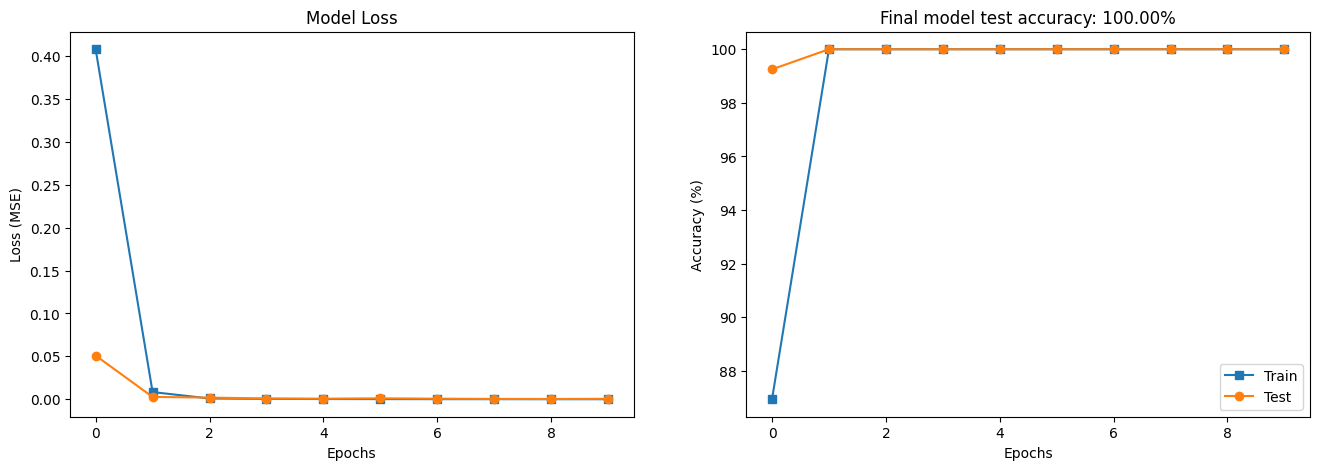

In [25]:
fig, ax = plt.subplots(1,2,figsize=(16,5))

ax[0].plot(train_losses, 's-', label = 'Train')
ax[0].plot(test_losses, 'o-', label = 'Test')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss (MSE)')
ax[0].set_title('Model Loss')

ax[1].plot(train_accs, 's-', label = 'Train')
ax[1].plot(test_accs, 'o-', label = 'Test')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Accuracy (%)')
ax[1].set_title(f'Final model test accuracy: {test_accs[-1]:.2f}%')
ax[1].legend()

plt.show()

## Visualize Images

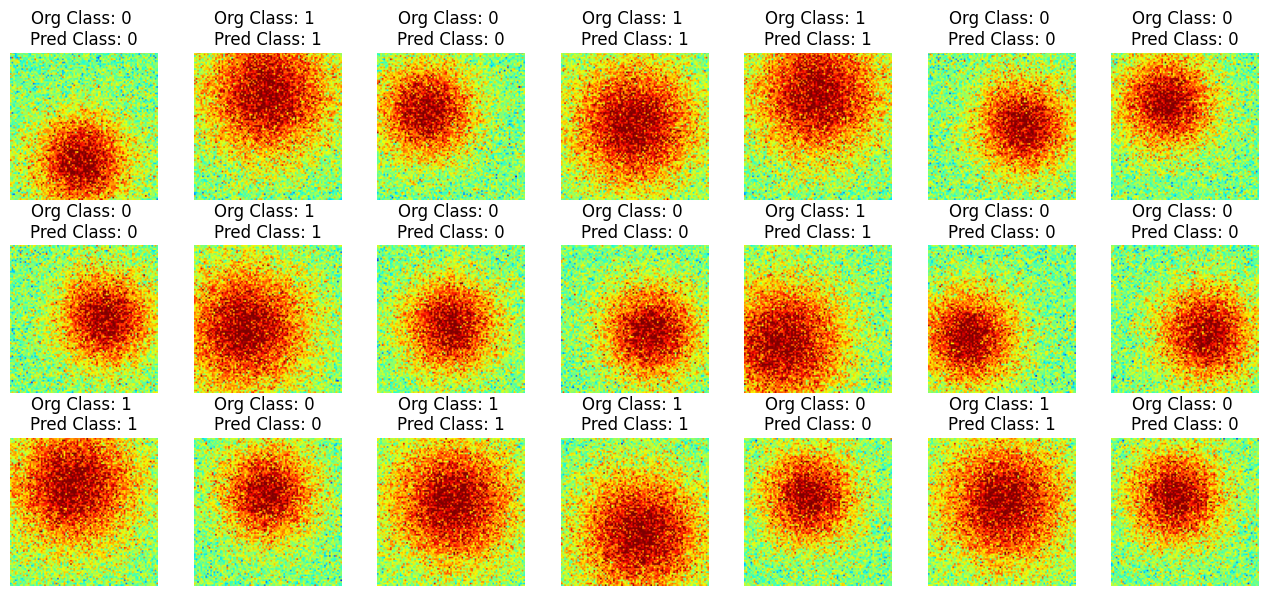

In [26]:
X, y = next(iter(train_dataloader))
y_hat = net(X)[0]

fig, axs = plt.subplots(3, 7, figsize = (13, 6))

for i, ax in enumerate(axs.flatten()):
  rand_row = np.random.randint(X.shape[0])
  image = X[rand_row]
  ax.imshow(image.squeeze(), vmin = -1, vmax = 1, cmap = 'jet')
  ax.set_title(f'Org Class: {y[rand_row].item():.0f} \nPred Class: {int(y_hat[rand_row].item()>0)}')
  ax.axis('off')
  ax.set_xticks([])
  ax.set_yticks([])

plt.tight_layout()
plt.show()

## Draw Feature Maps

### feature_map_1

In [27]:
feature_map_1.shape

torch.Size([32, 6, 91, 91])

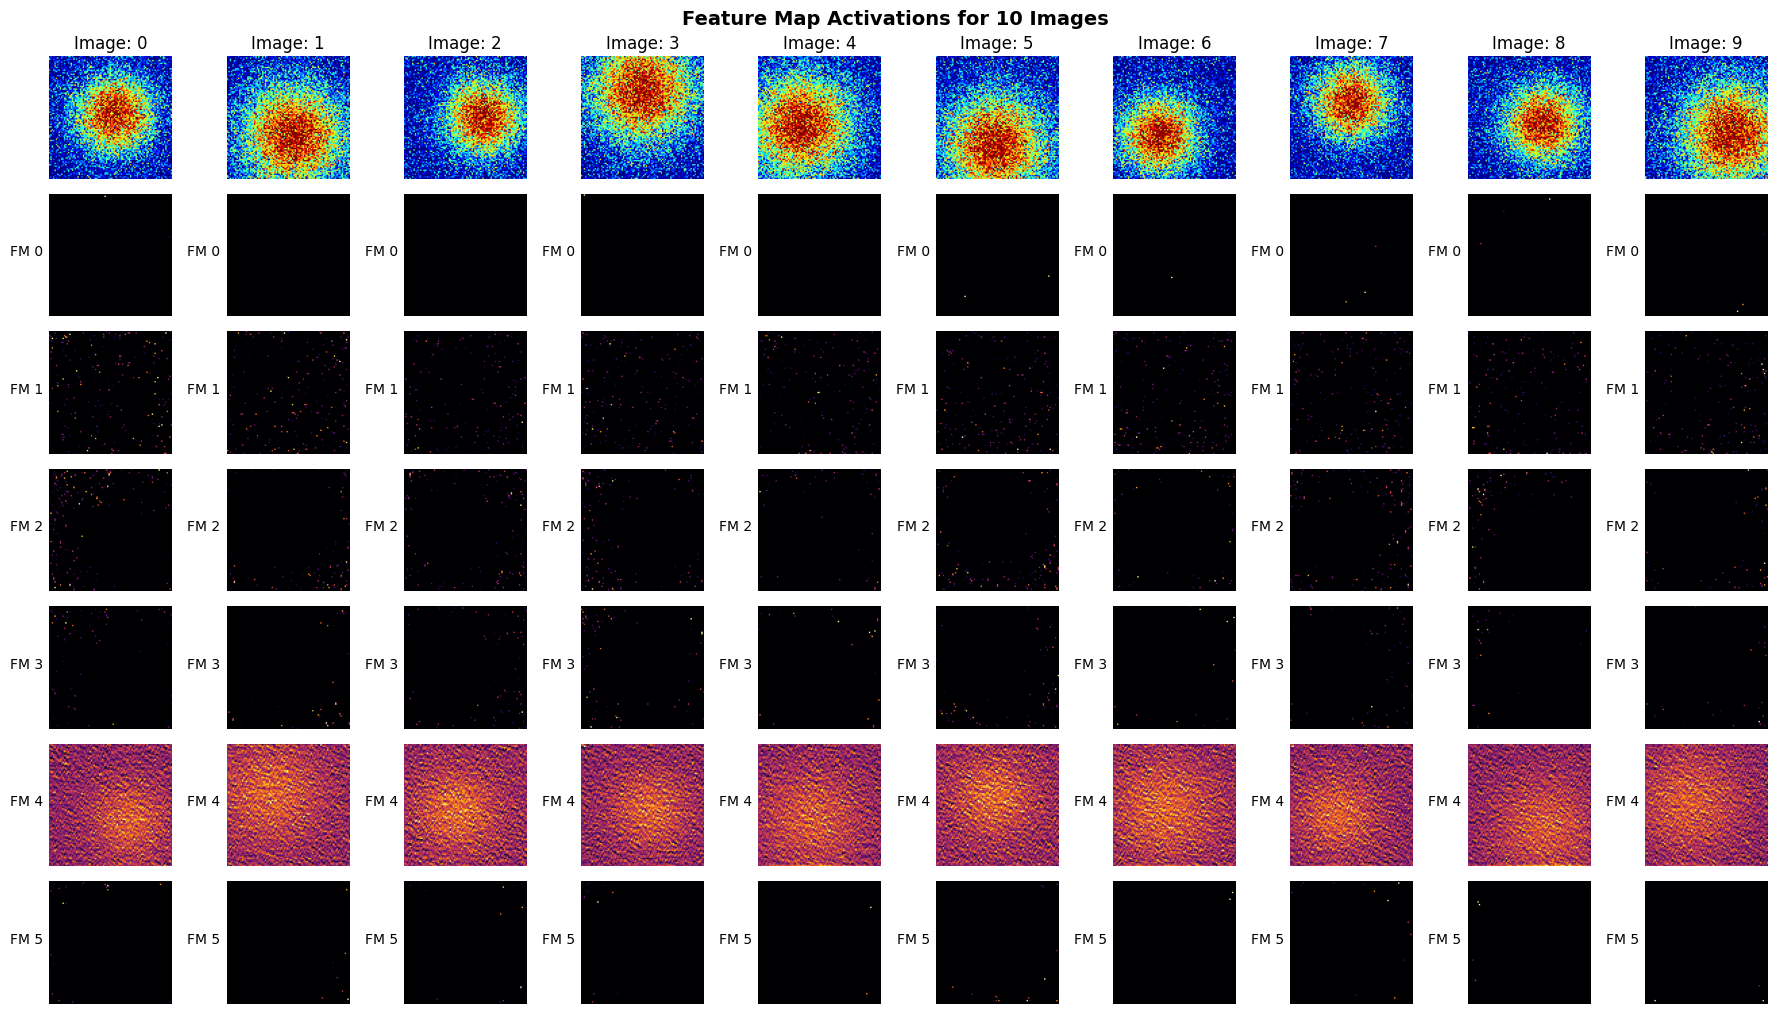

In [28]:
fig, axs = plt.subplots(7, 10, figsize = (18, 10))

for pic in range(10):
  axs[0][pic].imshow(X[pic,:,:,:].squeeze(), cmap = 'jet', vmin = 0, vmax = 1)
  axs[0][pic].set_title(f'Image: {pic}')
  axs[0][pic].axis('off')

  for fm in range(6):
    img = feature_map_1[pic,fm,:,:].detach().squeeze()
    axs[fm+1][pic].imshow(img,
                          cmap = 'inferno',
                          vmin = 0,
                          vmax = torch.max(img)*.9,
                          )
    axs[fm+1][pic].axis('off')
    axs[fm+1][pic].text(-5, 45, f'FM {fm}', ha = 'right')

plt.tight_layout()
plt.suptitle('Feature Map Activations for 10 Images',
             x = .5,
             y = 1.01,
             fontweight = 'bold',
             fontsize = 14)
plt.show()

### feature_map_2

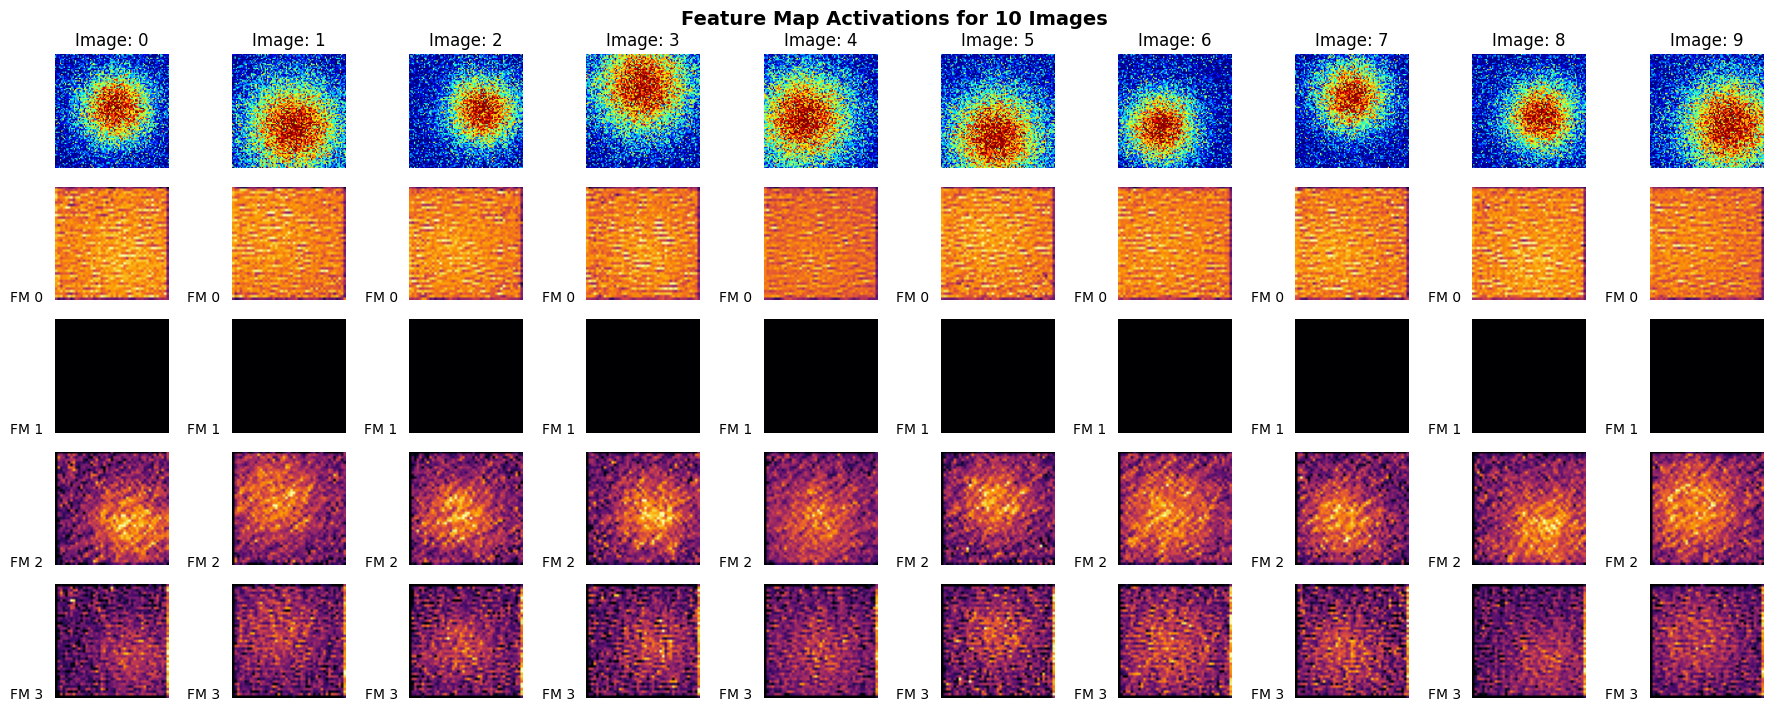

In [29]:
fig, axs = plt.subplots(5, 10, figsize = (18, 7))

for pic in range(10):
  axs[0][pic].imshow(X[pic,:,:,:].squeeze(), cmap = 'jet', vmin = 0, vmax = 1)
  axs[0][pic].set_title(f'Image: {pic}')
  axs[0][pic].axis('off')

  for fm in range(4):
    img = feature_map_2[pic,fm,:,:].detach().squeeze()
    axs[fm+1][pic].imshow(img,
                          cmap = 'inferno',
                          vmin = 0,
                          vmax = torch.max(img)*.9,
                          )
    axs[fm+1][pic].axis('off')
    axs[fm+1][pic].text(-5, 45, f'FM {fm}', ha = 'right')

plt.tight_layout()
plt.suptitle('Feature Map Activations for 10 Images',
             x = .5,
             y = 1.01,
             fontweight = 'bold',
             fontsize = 14)
plt.show()

## Spatial Correlations Across Feature Maps

### feature_map_1

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


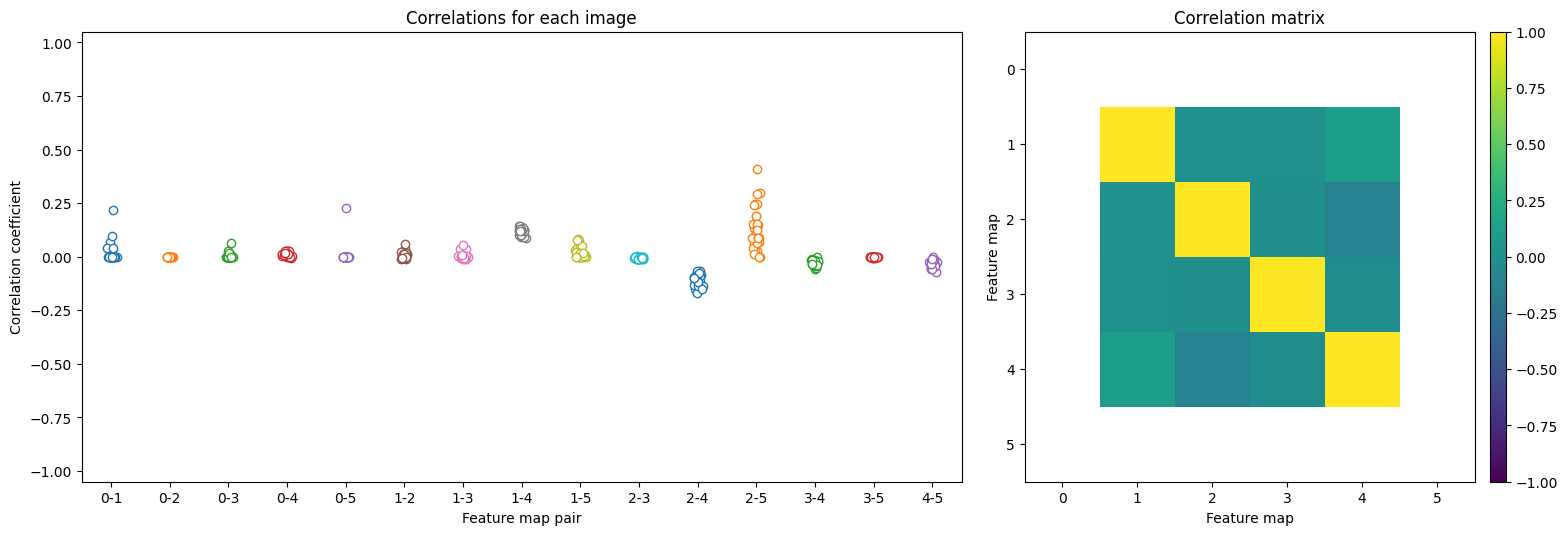

In [30]:
### correlations across the second convolution layer - feature_map_2

# convenient variables
n_stim = feature_map_1.shape[0]
n_maps = feature_map_1.shape[1]
n_cors = (n_maps*(n_maps-1))//2

# initialize the matrix of all correlation values
all_rs = np.zeros((n_stim, n_cors))
call = np.zeros((n_maps, n_maps))

# loop over each-stimulus
for i in range(n_stim):

  # extract the vectorized feature maps from this image
  feature_maps = feature_map_1[i,:,:,:].view(n_maps, -1).detach()

  # compute the correlation matrix
  c = np.corrcoef(feature_maps)
  call += c

  # extract the unique correlations from the matrix
  idx = np.nonzero(np.triu(c,1))
  all_rs[i,:] = c[idx]

# define the x-axis labels
x_lab = []*n_cors
for i in range(n_cors):
  x_lab.append('%s-%s'%(idx[0][i], idx[1][i]))

# now visualize the correlations
fig = plt.figure(figsize = (16,5))
ax0 = fig.add_axes([.1,.1,.55,.9]) # [left, bottom, width, height]
ax1 = fig.add_axes([.68, .1, .3, .9])
cax = fig.add_axes([.98,.1,.01,.9])

for i in range(n_cors):
  ax0.plot(i + np.random.randn(n_stim)/30, all_rs[:,i], 'o', markerfacecolor = 'w')

# make the plot more interpretable
ax0.set_xlim([-.5, n_cors-.5])
ax0.set_ylim([-1.05,1.05])
ax0.set_xticks(range(n_cors))
ax0.set_xticklabels(x_lab)
ax0.set_xlabel('Feature map pair')
ax0.set_ylabel('Correlation coefficient')
ax0.set_title('Correlations for each image')

# now show the average correlation matrix
h = ax1.imshow(call/n_stim, vmin=-1, vmax = 1)
ax1.set_title('Correlation matrix')
ax1.set_xlabel('Feature map')
ax1.set_ylabel('Feature map')
# add a colorbar
fig.colorbar(h, cax = cax)

plt.show()

### feature_map_2

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


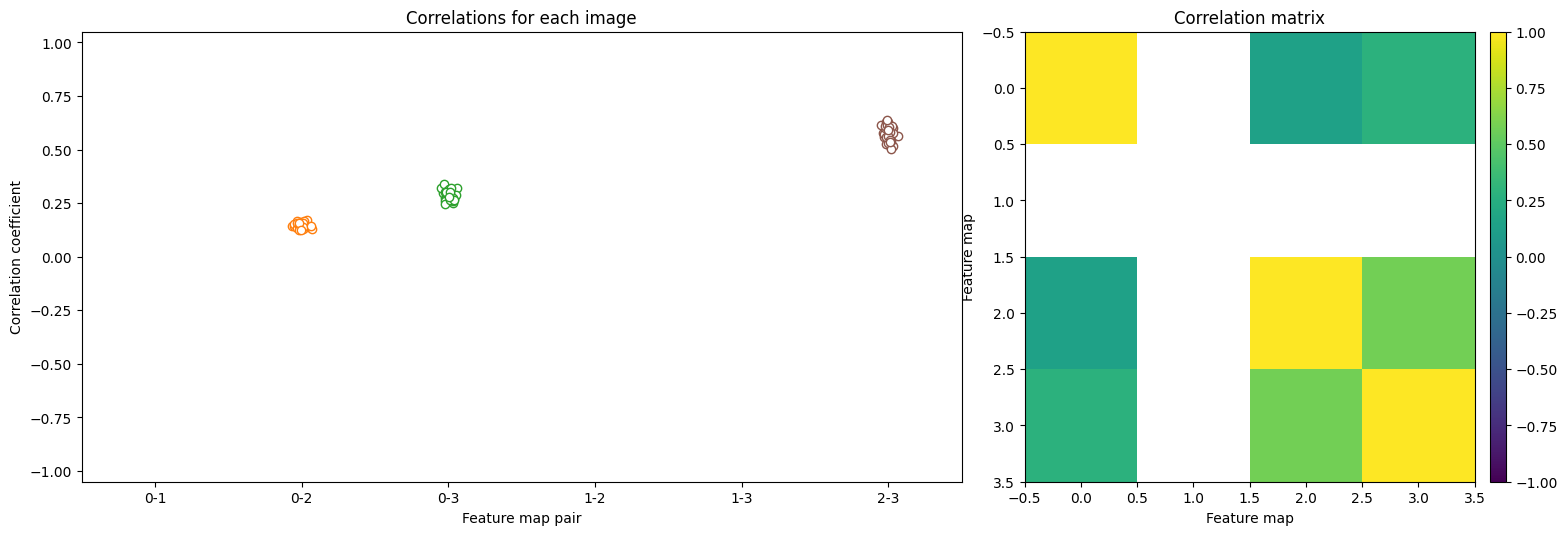

In [31]:
### correlations across the second convolution layer - feature_map_2

# convenient variables
n_stim = feature_map_2.shape[0]
n_maps = feature_map_2.shape[1]
n_cors = (n_maps*(n_maps-1))//2

# initialize the matrix of all correlation values
all_rs = np.zeros((n_stim, n_cors))
call = np.zeros((n_maps, n_maps))

# loop over each-stimulus
for i in range(n_stim):

  # extract the vectorized feature maps from this image
  feature_maps = feature_map_2[i,:,:,:].view(n_maps, -1).detach()

  # compute the correlation matrix
  c = np.corrcoef(feature_maps)
  call += c

  # extract the unique correlations from the matrix
  idx = np.nonzero(np.triu(c,1))
  all_rs[i,:] = c[idx]

# define the x-axis labels
x_lab = []*n_cors
for i in range(n_cors):
  x_lab.append('%s-%s'%(idx[0][i], idx[1][i]))

# now visualize the correlations
fig = plt.figure(figsize = (16,5))
ax0 = fig.add_axes([.1,.1,.55,.9]) # [left, bottom, width, height]
ax1 = fig.add_axes([.68, .1, .3, .9])
cax = fig.add_axes([.98,.1,.01,.9])

for i in range(n_cors):
  ax0.plot(i + np.random.randn(n_stim)/30, all_rs[:,i], 'o', markerfacecolor = 'w')

# make the plot more interpretable
ax0.set_xlim([-.5, n_cors-.5])
ax0.set_ylim([-1.05,1.05])
ax0.set_xticks(range(n_cors))
ax0.set_xticklabels(x_lab)
ax0.set_xlabel('Feature map pair')
ax0.set_ylabel('Correlation coefficient')
ax0.set_title('Correlations for each image')

# now show the average correlation matrix
h = ax1.imshow(call/n_stim, vmin=-1, vmax = 1)
ax1.set_title('Correlation matrix')
ax1.set_xlabel('Feature map')
ax1.set_ylabel('Feature map')
# add a colorbar
fig.colorbar(h, cax = cax)

plt.show()

## Conclussion

* Weights are fixed, feature layer activations require data

* Convolution layers learn features but don't make decisions; fully-connected layers use those features to make decisions

* Feature map activations can (should!) be qualitatively and quantitatively inspected. Empty or near-identical maps indicate gratuitous complexity.

* Simple models are "easy" to inspect; larger models become incresingly difficult. Develop the habit of thinking critically about model architecture.